# Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [47]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# Basic Information

In [48]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0           

In [49]:
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [50]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [51]:
print("\n=== Target Variable (Exited) Distribution ===")
print(df['Exited'].value_counts())
print("\nPercentage:")
print(df['Exited'].value_counts(normalize=True) * 100)


=== Target Variable (Exited) Distribution ===
Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


# Data Cleaning & Feature Selection

In [52]:
# Create a working copy
df_clean = df.copy()

# Drop unnecessary columns
df_clean = df_clean.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("After Dropping Unnecessary Columns:")
print("Shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

# Check unique values in categorical columns
print("\nUnique Values:")
print("Geography:", df_clean['Geography'].unique())
print("Gender:", df_clean['Gender'].unique())

After Dropping Unnecessary Columns:
Shape: (10000, 11)
Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Unique Values:
Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']


# EDA & Visualizations

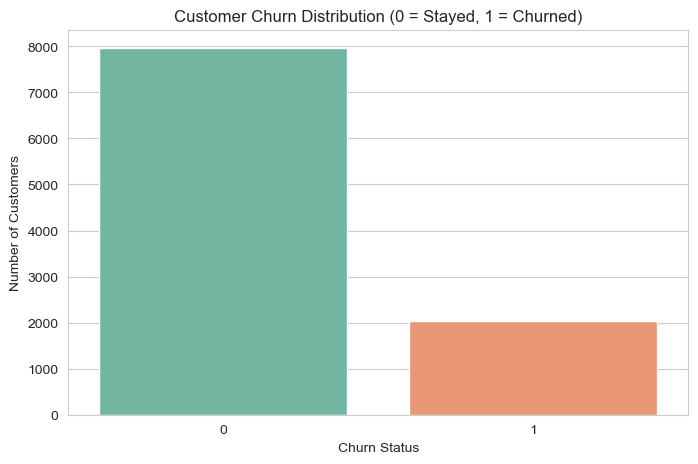

In [53]:
# 1. Churn Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Exited', data=df_clean, palette='Set2')
plt.title('Customer Churn Distribution (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

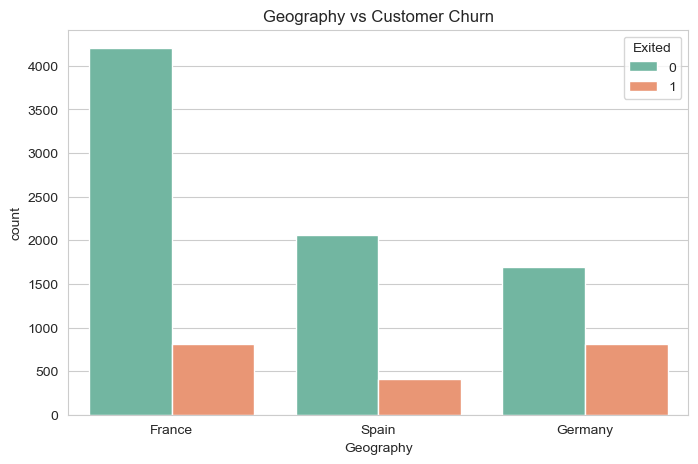

In [54]:
# 2. Geography vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Geography', hue='Exited', data=df_clean, palette='Set2')
plt.title('Geography vs Customer Churn')
plt.show()

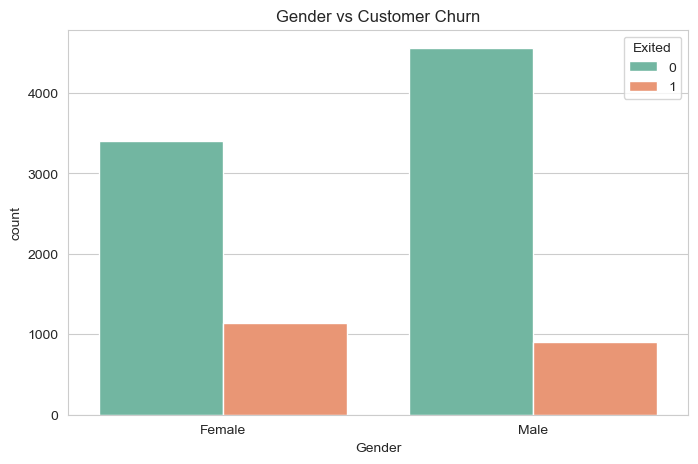

In [55]:
# 3. Gender vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Exited', data=df_clean, palette='Set2')
plt.title('Gender vs Customer Churn')
plt.show()


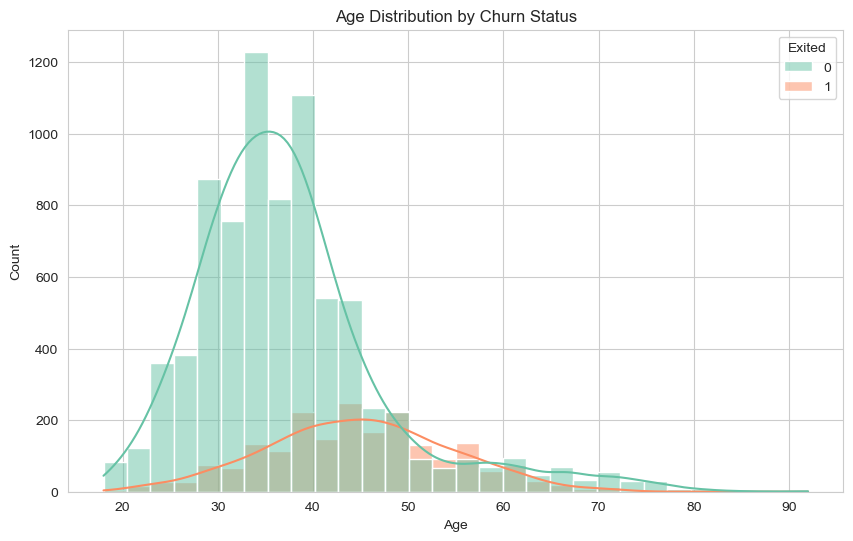

In [56]:
# 4. Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean, x='Age', hue='Exited', kde=True, bins=30, palette='Set2')
plt.title('Age Distribution by Churn Status')
plt.show()

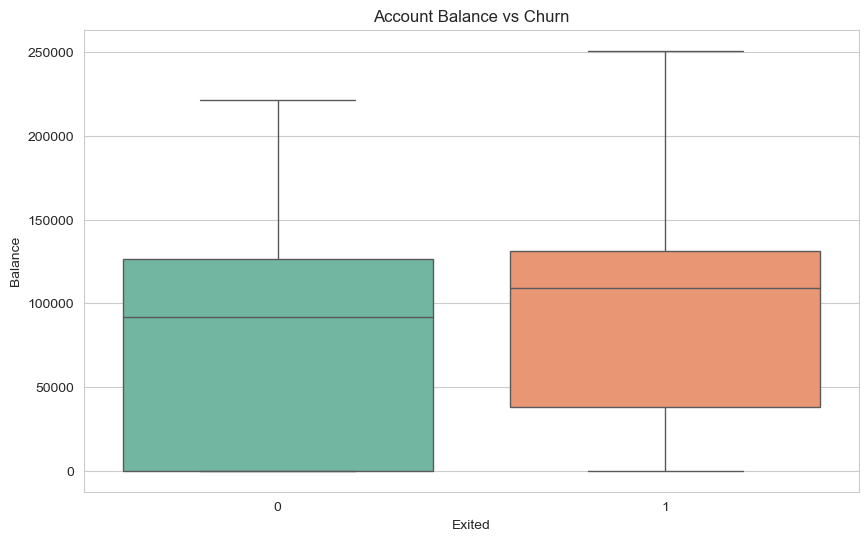

In [57]:
# 5. Balance vs Churn
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited', y='Balance', data=df_clean, palette='Set2')
plt.title('Account Balance vs Churn')
plt.show()


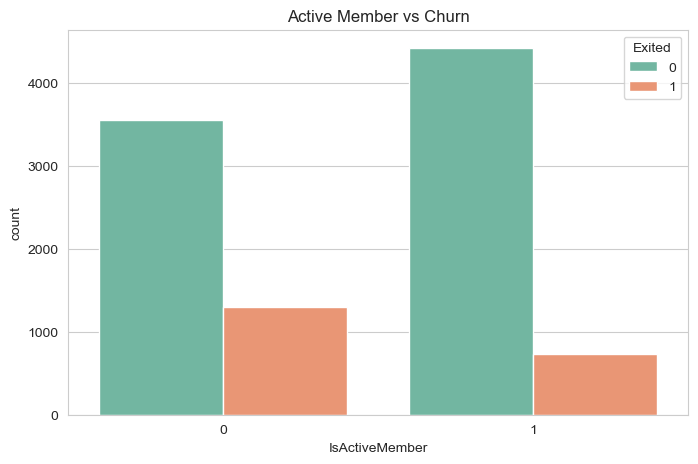

In [58]:
# 6. IsActiveMember vs Churn (Very Important)
plt.figure(figsize=(8,5))
sns.countplot(x='IsActiveMember', hue='Exited', data=df_clean, palette='Set2')
plt.title('Active Member vs Churn')
plt.show()

# Feature Encoding

In [59]:
# Create copy for modeling
df_model = df_clean.copy()

# Label Encoding for Gender (Binary)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])

# One-Hot Encoding for Geography (3 categories)
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

print("=== After Encoding ===")
print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())
print("\nSample Data:")
print(df_model.head())

=== After Encoding ===
Shape: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Sample Data:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False   

# Train-Test Split & Model Building

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate Features and Target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8000, 11)
Testing Shape: (2000, 11)


# Model 1: Logistic Regression

In [61]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print(classification_report(y_test, y_pred_log))



=== Logistic Regression Results ===
Accuracy: 0.8165
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.59      0.22      0.32       393

    accuracy                           0.82      2000
   macro avg       0.71      0.59      0.61      2000
weighted avg       0.79      0.82      0.78      2000



# Model 2: Random Forest (Recommended)

In [62]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf))


=== Random Forest Results ===
Accuracy: 0.8625
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.77      0.43      0.55       393

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



# Confusion Matrix

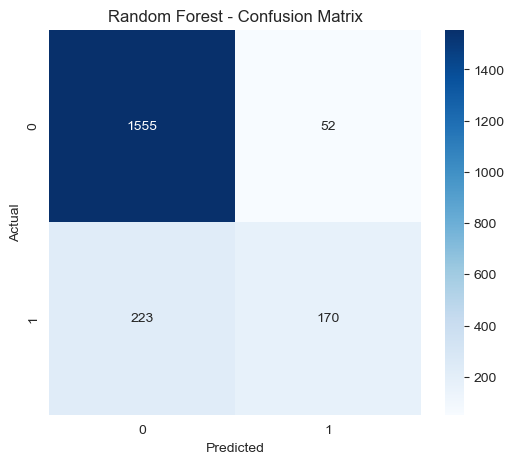

Confusion Matrix Values:
[[1555   52]
 [ 223  170]]


In [63]:
import seaborn as sns

# Random Forest Confusion Matrix (Best Model)
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix Values:")
print(cm)

# Feature Importance Analysis

In [64]:
# Get Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10))


=== Top 10 Most Important Features ===
              Feature  Importance
2                 Age    0.354357
5       NumOfProducts    0.274120
4             Balance    0.084713
7      IsActiveMember    0.082866
9   Geography_Germany    0.051531
0         CreditScore    0.049113
8     EstimatedSalary    0.047403
3              Tenure    0.025843
1              Gender    0.017357
10    Geography_Spain    0.006588


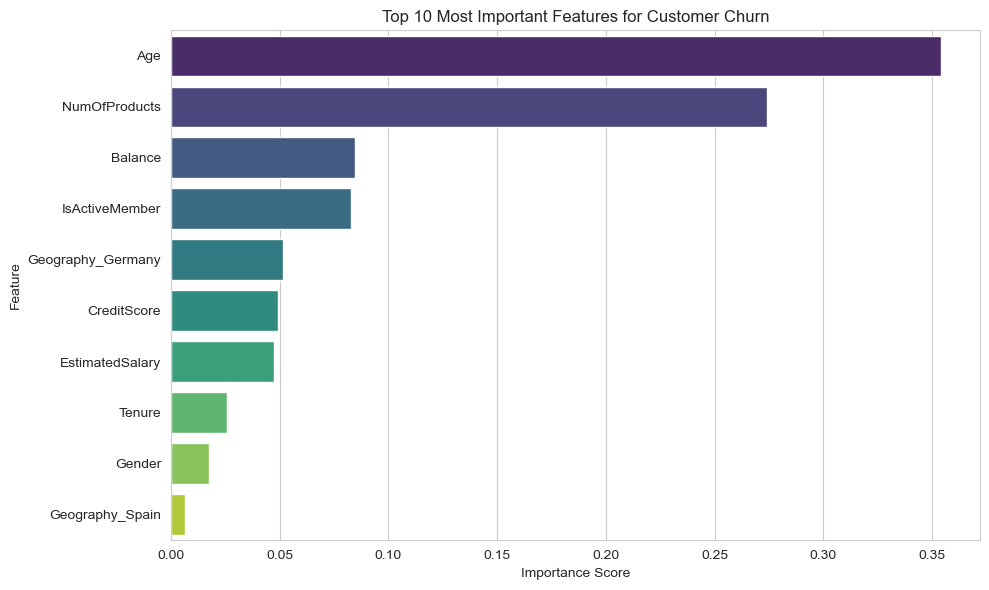

In [65]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Customer Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Conclusion & Key Insights


## Task Summary
- Successfully built a Customer Churn Prediction model for a Bank.
- Dataset contained 10,000 customer records with 14 features.
- Target variable (`Exited`) was imbalanced (20.37% churn rate).

## Data Preprocessing
- Dropped irrelevant columns (`RowNumber`, `CustomerId`, `Surname`).
- Handled categorical features using Label Encoding (`Gender`) and One-Hot Encoding (`Geography`).
- No missing values were present in the dataset.

## Model Performance
- **Logistic Regression**: Accuracy = 81.65%
- **Random Forest**: Accuracy = **86.25%** (Best Model)

## Key Business Insights (Feature Importance)
- Most important factors affecting customer churn:
  1. **Age** — Older customers are more likely to churn.
  2. **Balance** — Customers with high balance tend to leave.
  3. **IsActiveMember** — Inactive members have higher churn rate.
  4. **Geography** (especially Germany) — Significant impact.
  5. **NumOfProducts** — Customers with more products show different behavior.

## Recommendations for Bank
- Focus retention efforts on **older customers** and **high-balance customers**.
- Increase engagement with **inactive members**.
- Special attention needed for customers from **Germany**.
- Improve services for customers having multiple products.

## Skills Demonstrated
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Categorical Feature Encoding
- Classification Modeling
- Feature Importance Analysis
- Business Insights Generation

**This notebook fulfills all the requirements of Task 3 as per DevelopersHub guidelines.**